### Implementing Simple Chatbot Using LangGraph

In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [5]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [3]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model_name="gpt-4o")
llm.invoke("Hello")

c:\Users\Karan\Desktop\agentic-ai-langchain-langgraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e1dc348028', 'id': 'chatcmpl-CnqzfUatPihL25FjlE4bNPPzxlvKO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--b176feb4-42ad-4e05-aa00-4ff5ee92415a-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [8]:
from langchain_groq import ChatGroq
llm_groq = ChatGroq(model_name="llama-3.3-70b-versatile")
llm_groq.invoke("Hello I'm Karan, I was an esports athlete before transitioning into AI.")

AIMessage(content="Hello Karan, it's great to meet you. That's a fascinating career transition - from being an esports athlete to working in AI. Esports requires a unique combination of skill, strategy, and quick thinking, while AI involves working with complex algorithms and data analysis.\n\nWhat inspired you to make the switch, and how do you think your experience as an esports athlete has prepared you for a career in AI? Are you working on any specific projects or applications of AI that you're excited about?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 51, 'total_tokens': 151, 'completion_time': 0.348605414, 'completion_tokens_details': None, 'prompt_time': 0.002470122, 'prompt_tokens_details': None, 'queue_time': 0.042722239, 'total_time': 0.351075536}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'gr

### Creating Nodes

In [10]:
def superbot(state:State):
    return {"messages": [llm_groq.invoke(state['messages'])]}
    

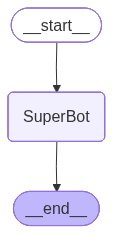

In [13]:
graph = StateGraph(State)

## Node
graph.add_node("SuperBot", superbot)

## Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

## Compile

graph_builder = graph.compile()

## Display
from IPython.display import display, Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [14]:
## Invocation

graph_builder.invoke({'messages': ["Hello, My name is Karan, I was an esports athlete before transitioning into AI."]})

{'messages': [HumanMessage(content='Hello, My name is Karan, I was an esports athlete before transitioning into AI.', additional_kwargs={}, response_metadata={}, id='fcc34050-a104-47a0-a3b9-d4b8d2856d13'),
  AIMessage(content="Nice to meet you, Karan. That's a fascinating career transition - from being an esports athlete to working in AI. Esports requires a high level of skill, strategy, and teamwork, while AI involves a more technical and analytical approach.\n\nWhat motivated you to make the switch, and how do you think your experience in esports has helped or hindered your transition into the AI field? Are you working on any specific projects or applications of AI that you're excited about?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 53, 'total_tokens': 149, 'completion_time': 0.322443412, 'completion_tokens_details': None, 'prompt_time': 0.006896448, 'prompt_tokens_details': None, 'queue_time': 0.140923245, 'total_time': 0.32

### Streaming the responses

In [20]:
for event in graph_builder.stream({'messages': ["Hello, My name is Karan, I was an esports athlete before transitioning into AI."]}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='Hello, My name is Karan, I was an esports athlete before transitioning into AI.', additional_kwargs={}, response_metadata={}, id='0b21311d-e19f-4f7b-932a-35088268fa46')]}
{'messages': [HumanMessage(content='Hello, My name is Karan, I was an esports athlete before transitioning into AI.', additional_kwargs={}, response_metadata={}, id='0b21311d-e19f-4f7b-932a-35088268fa46'), AIMessage(content="Nice to meet you, Karan. That's a fascinating career transition - from being an esports athlete to working in AI. Esports requires a high level of skill, strategy, and teamwork, while AI involves working with complex algorithms and data.\n\nWhat inspired you to make the switch, and how do you think your experience as an esports athlete has helped or influenced your work in AI? Are you working on any specific projects or applications of AI that you're excited about?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens